# Reto: Comparación de los 2 conjuntos de datos

Se comparan las etiquetas **originales** de MASATI-v2 (dibujadas a mano por personas) contra las etiquetas **ajustadas por SAM** (`ships_SAM/`, generadas en el reto anterior usando la caja original como *prompt*).


In [1]:
from pathlib import Path
import random
import xml.etree.ElementTree as ET

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


BASE = Path("MASATI-v2")
if not BASE.exists():
    BASE = Path.home() / "Downloads" / "MASATI-v2"
SAM_DIR = Path("ships_SAM")
if not SAM_DIR.exists():
    SAM_DIR = BASE / "ships_SAM"

COLOR_ORIG = (0, 200, 0)   # RGB: verde  -> etiqueta original
COLOR_SAM = (255, 0, 0)    # RGB: rojo   -> etiqueta SAM

SEED = 42
random.seed(SEED)

CATEGORY_NAMES = {"ship": "Un solo barco", "coast_ship": "Barco con costa", "multi": "Múltiples barcos"}

## Funciones auxiliares

In [2]:
def read_xml(xml_path):
    """Devuelve (carpeta, nombre de archivo, lista de cajas (xmin, ymin, xmax, ymax))."""
    root = ET.parse(xml_path).getroot()
    boxes = []
    for obj in root.findall("object"):
        bb = obj.find("bndbox")
        boxes.append(tuple(int(bb.find(k).text) for k in ("xmin", "ymin", "xmax", "ymax")))
    return root.find("folder").text, root.find("filename").text, boxes


def box_area(b):
    return max(0, b[2] - b[0]) * max(0, b[3] - b[1])


def iou(a, b):
    """IoU entre dos cajas (xmin, ymin, xmax, ymax)."""
    ix = max(0, min(a[2], b[2]) - max(a[0], b[0]))
    iy = max(0, min(a[3], b[3]) - max(a[1], b[1]))
    inter = ix * iy
    union = box_area(a) + box_area(b) - inter
    return inter / union if union > 0 else 0.0


# Comprobaciones rápidas de la métrica
assert iou((0, 0, 10, 10), (0, 0, 10, 10)) == 1.0
assert iou((0, 0, 10, 10), (20, 20, 30, 30)) == 0.0
assert abs(iou((0, 0, 10, 10), (5, 0, 15, 10)) - 1 / 3) < 1e-9

## Carga y emparejamiento de las etiquetas originales y las de SAM

In [3]:
pairs = []  # un elemento por imagen
for sam_xml in sorted(SAM_DIR.glob("*.xml")):
    folder, filename, boxes_sam = read_xml(sam_xml)
    orig_xml = BASE / f"{folder}_labels" / sam_xml.name
    _, _, boxes_orig = read_xml(orig_xml)
    if len(boxes_orig) != len(boxes_sam):
        print(f"[AVISO] {sam_xml.name}: {len(boxes_orig)} cajas originales vs {len(boxes_sam)} SAM -> se omite")
        continue
    pairs.append({"folder": folder, "file": filename, "orig": boxes_orig, "sam": boxes_sam,
                  "image": BASE / folder / filename})

df_pairs = pd.DataFrame(pairs)
print(f"Imágenes emparejadas: {len(df_pairs)}  |  cajas totales: {sum(len(p['orig']) for p in pairs)}")
df_pairs.assign(n_cajas=df_pairs["orig"].map(len)).groupby("folder").agg(imagenes=("file", "count"), cajas=("n_cajas", "sum"))

Imágenes emparejadas: 21  |  cajas totales: 39


,imagenes,cajas
folder,,
coast_ship,7,7
multi,7,25
ship,7,7


## Etiqueta original (verde) vs. etiqueta SAM (rojo)

Se eligen 2 imágenes aleatorias de cada tipo. El número junto a cada caja es su IoU.

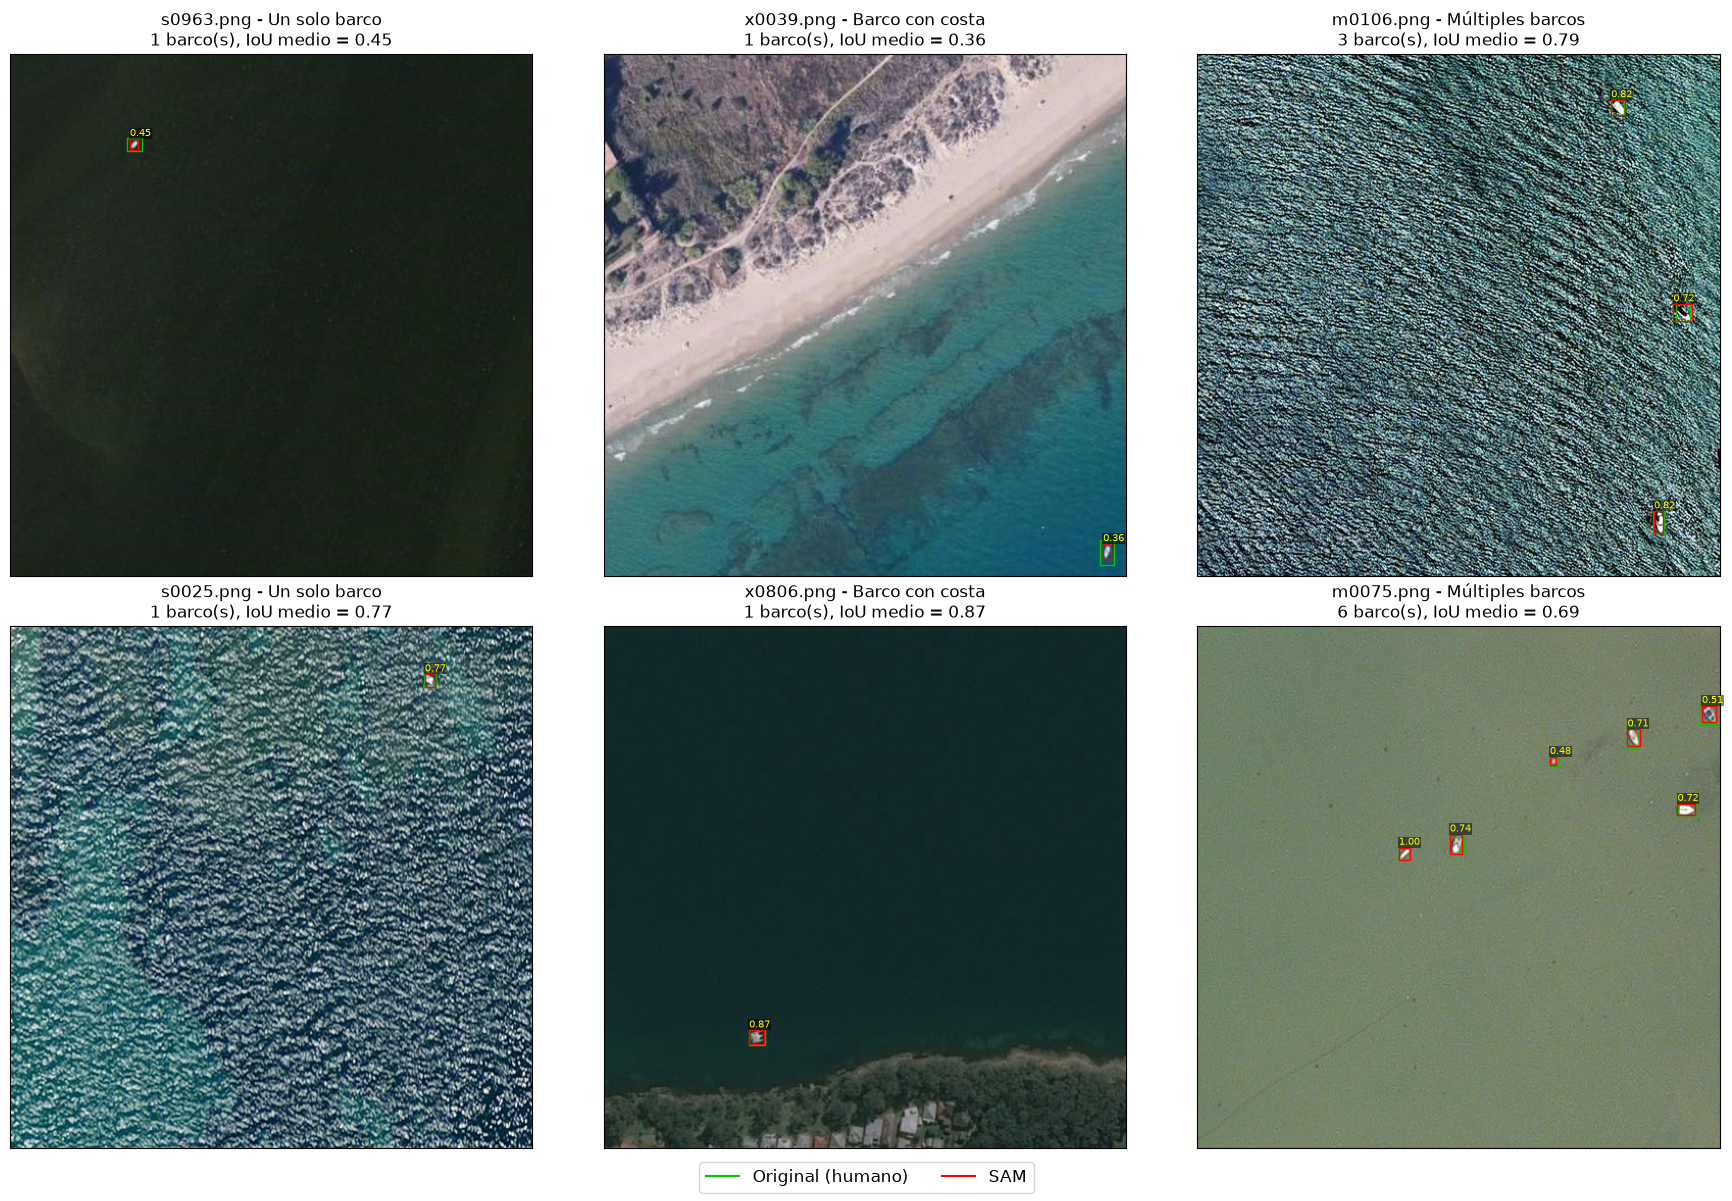

In [4]:
def load_rgb(path):
    return cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)


def draw_comparison(ax, pair, show_iou=True, lw=1.0):
    img = load_rgb(pair["image"])
    ax.imshow(img)
    for bo, bs in zip(pair["orig"], pair["sam"]):
        for b, c in ((bo, COLOR_ORIG), (bs, COLOR_SAM)):
            ax.add_patch(plt.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False, edgecolor=np.array(c) / 255, linewidth=lw))
        if show_iou:
            ax.text(bs[0], max(bs[1] - 3, 8), f"{iou(bo, bs):.2f}", color="yellow", fontsize=7,
                    bbox=dict(facecolor="black", alpha=0.5, pad=0.5, edgecolor="none"))
    ax.set_xticks([]); ax.set_yticks([])


rng = random.Random(SEED)
samples = []
for cat in ("ship", "coast_ship", "multi"):
    cands = [p for p in pairs if p["folder"] == cat]
    samples += rng.sample(cands, 2)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for i, p in enumerate(samples):
    ax = axes[i % 2, i // 2]
    draw_comparison(ax, p)
    ious = [iou(a, b) for a, b in zip(p["orig"], p["sam"])]
    ax.set_title(f"{p['file']} - {CATEGORY_NAMES[p['folder']]}\n{len(ious)} barco(s), IoU medio = {np.mean(ious):.2f}")
fig.legend(handles=[plt.Line2D([], [], color=np.array(COLOR_ORIG) / 255, label="Original (humano)"),
                    plt.Line2D([], [], color=np.array(COLOR_SAM) / 255, label="SAM")],
           loc="lower center", ncol=2, fontsize=12)
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

### Zoom sobre los barcos

Recorte ampliado alrededor de cada barco (primer barco de cada imagen anterior) para apreciar mejor cuánto difieren las cajas.

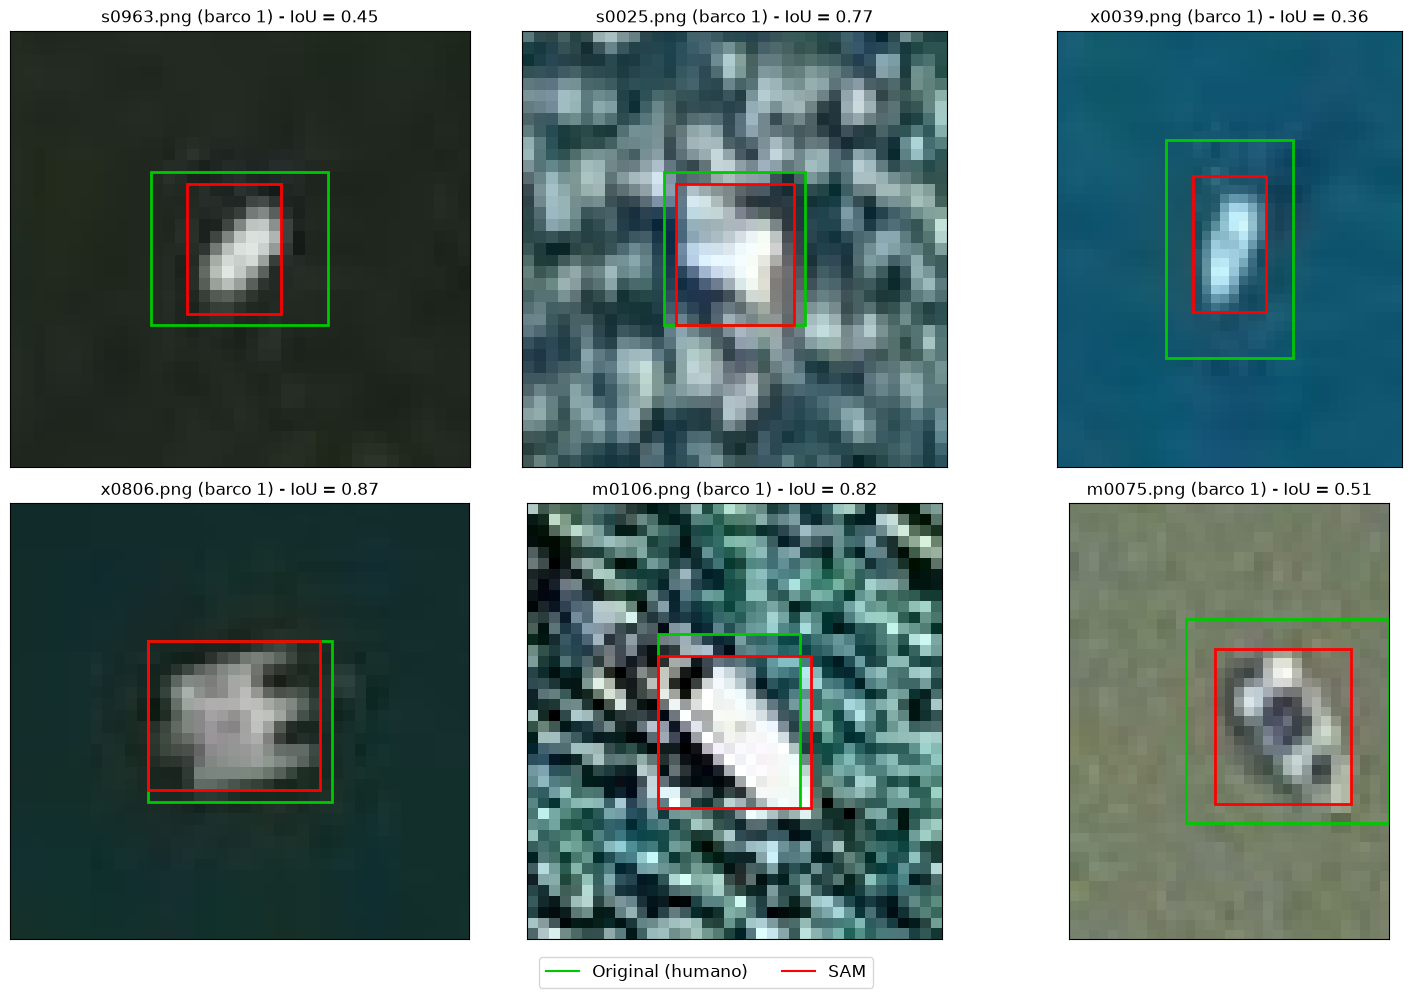

In [5]:
def zoom_crop(pair, idx=0, margin=12):
    img = load_rgb(pair["image"])
    bo, bs = pair["orig"][idx], pair["sam"][idx]
    x1 = max(0, min(bo[0], bs[0]) - margin); y1 = max(0, min(bo[1], bs[1]) - margin)
    x2 = min(img.shape[1], max(bo[2], bs[2]) + margin); y2 = min(img.shape[0], max(bo[3], bs[3]) + margin)
    return img[y1:y2, x1:x2], (bo[0] - x1, bo[1] - y1, bo[2] - x1, bo[3] - y1), (bs[0] - x1, bs[1] - y1, bs[2] - x1, bs[3] - y1)


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, p in zip(axes.ravel(), samples):
    crop, bo, bs = zoom_crop(p)
    ax.imshow(crop)
    for b, c in ((bo, COLOR_ORIG), (bs, COLOR_SAM)):
        ax.add_patch(plt.Rectangle((b[0] - 0.5, b[1] - 0.5), b[2] - b[0], b[3] - b[1], fill=False,
                                   edgecolor=np.array(c) / 255, linewidth=2))
    ax.set_title(f"{p['file']} (barco 1) - IoU = {iou(p['orig'][0], p['sam'][0]):.2f}")
    ax.set_xticks([]); ax.set_yticks([])
fig.legend(handles=[plt.Line2D([], [], color=np.array(COLOR_ORIG) / 255, label="Original (humano)"),
                    plt.Line2D([], [], color=np.array(COLOR_SAM) / 255, label="SAM")],
           loc="lower center", ncol=2, fontsize=12)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

## Medición cuantitativa: IoU por caja

Tabla con una fila por barco: tamaño de cada caja, razón de áreas (SAM / original) y su IoU.

In [6]:
rows = []
for p in pairs:
    for i, (bo, bs) in enumerate(zip(p["orig"], p["sam"])):
        ao, as_ = box_area(bo), box_area(bs)
        rows.append({"categoria": p["folder"], "imagen": p["file"], "barco": i + 1,
                     "area_orig": ao, "area_sam": as_, "razon_area": as_ / ao if ao else np.nan,
                     "iou": iou(bo, bs)})
df = pd.DataFrame(rows)

# Verificación de alineación: el IoU con la caja del mismo índice no debería ser peor que el mejor emparejamiento posible
mis = 0
for p in pairs:
    for i, bo in enumerate(p["orig"]):
        if max(iou(bo, bs) for bs in p["sam"]) > iou(bo, p["sam"][i]) + 1e-9:
            mis += 1
print(f"Cajas con posible desalineación de índice: {mis}")
assert df["iou"].between(0, 1).all()
df.round(3)

Cajas con posible desalineación de índice: 0


,categoria,imagen,barco,area_orig,area_sam,razon_area,iou
0,multi,m0021.png,1,476,384,0.807,0.762
1,multi,m0021.png,2,684,608,0.889,0.718
2,multi,m0021.png,3,99,100,1.010,0.826
3,multi,m0075.png,1,441,224,0.508,0.508
4,multi,m0075.png,2,231,192,0.831,0.713
5,multi,m0075.png,3,234,187,0.799,0.718
6,multi,m0075.png,4,224,228,1.018,0.738
7,multi,m0075.png,5,132,132,1.000,1.000
8,multi,m0075.png,6,99,48,0.485,0.485
9,multi,m0106.png,1,208,196,0.942,0.820


In [7]:
resumen = df.groupby("categoria")["iou"].agg(
    barcos="count", media="mean", mediana="median", minimo="min", maximo="max", desv_std="std",
    pct_iou_menor_05=lambda s: 100 * (s < 0.5).mean(),
).round(3)
resumen.loc["TOTAL"] = [len(df), df["iou"].mean(), df["iou"].median(), df["iou"].min(), df["iou"].max(),
                        df["iou"].std(), 100 * (df["iou"] < 0.5).mean()]
resumen.round(3)

,barcos,media,mediana,minimo,maximo,desv_std,pct_iou_menor_05
categoria,,,,,,,
coast_ship,7.0,0.630,0.573,0.357,0.871,0.190,14.286
multi,25.0,0.740,0.738,0.485,1.000,0.115,4.000
ship,7.0,0.588,0.599,0.393,0.769,0.137,28.571
TOTAL,39.0,0.693,0.713,0.357,1.000,0.146,10.256


In [8]:
# Por imagen (IoU medio de sus barcos)
por_imagen = df.groupby(["categoria", "imagen"]).agg(barcos=("iou", "count"), iou_medio=("iou", "mean"),
                                                     iou_min=("iou", "min"), iou_max=("iou", "max")).round(3)
por_imagen

barcos  iou_medio  iou_min  iou_max
categoria  imagen                                        
coast_ship x0039.png       1      0.357    0.357    0.357
           x0064.png       1      0.573    0.573    0.573
           x0227.png       1      0.562    0.562    0.562
           x0370.png       1      0.500    0.500    0.500
           x0794.png       1      0.684    0.684    0.684
           x0806.png       1      0.871    0.871    0.871
           x1023.png       1      0.866    0.866    0.866
multi      m0021.png       3      0.769    0.718    0.826
           m0075.png       6      0.694    0.485    1.000
           m0106.png       3      0.787    0.722    0.820
           m0129.png       3      0.705    0.625    0.832
           m0163.png       2      0.635    0.611    0.658
           m0182.png       5      0.812    0.697    0.917
           y0031.png       3      0.740    0.667    0.788
ship       s0025.png       1      0.769    0.769    0.769
           s0063.png       1      0.653    0.653    0.653
           s0187.png       1      0.393    0.393    0.393
           s0562.png       1      0.713    0.713    0.713
           s0593.png       1      0.537    0.537    0.537
           s0963.png       1      0.451    0.451    0.451
           s1010.png       1      0.599    0.599    0.599

Correlación (Pearson) log(área original) vs IoU: 0.142
SAM más pequeña que la original: 33 de 39 cajas (razón de área media = 0.79, mediana = 0.81)

Razón de área SAM/original por categoría:
             mean  median
categoria                
coast_ship  0.765   0.871
multi       0.839   0.818
ship        0.623   0.599


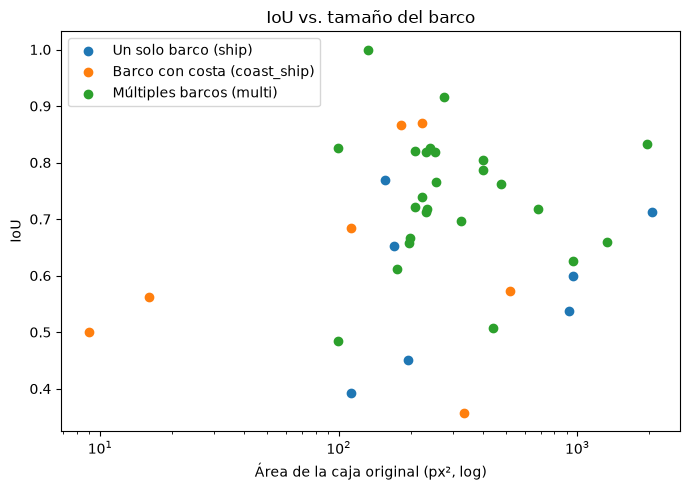

In [9]:
# Relación entre el tamaño de la caja y su IoU, y tamaño relativo de SAM frente a la etiqueta original
print(f"Correlación (Pearson) log(área original) vs IoU: {np.corrcoef(np.log(df['area_orig']), df['iou'])[0, 1]:.3f}")
print(f"SAM más pequeña que la original: {(df['razon_area'] < 1).sum()} de {len(df)} cajas "
      f"(razón de área media = {df['razon_area'].mean():.2f}, mediana = {df['razon_area'].median():.2f})")
print("\nRazón de área SAM/original por categoría:")
print(df.groupby("categoria")["razon_area"].agg(["mean", "median"]).round(3))

fig, ax = plt.subplots(figsize=(7, 5))
for cat, color in (("ship", "tab:blue"), ("coast_ship", "tab:orange"), ("multi", "tab:green")):
    sub = df[df["categoria"] == cat]
    ax.scatter(sub["area_orig"], sub["iou"], c=color, label=f"{CATEGORY_NAMES[cat]} ({cat})")
ax.legend()
ax.set_xscale("log"); ax.set_xlabel("Área de la caja original (px², log)"); ax.set_ylabel("IoU")
ax.set_title("IoU vs. tamaño del barco")
plt.tight_layout()
plt.show()

## Análisis y conclusiones

### Cualitativo (a partir de las imágenes)
- **Las cajas originales tienden a ser más holgadas.** En la mayoría de los zooms (`s0963`, `x0039`, `m0075`) el recuadro verde deja un margen apreciable de agua alrededor del barco, algo esperable porque fue dibujado manualmente con el mouse, donde es más cómodo "encerrar" el barco con margen que ajustarse al píxel.
- **La caja de SAM sigue el contorno de la máscara**, por lo que queda más ceñida al casco (recuadro rojo dentro del verde). Sin embargo, en barcos con bordes difusos (`x0806`, `s0025`) o con estela/sombra (`m0106`) la caja de SAM puede quedar desplazada o cortar un extremo del casco, mientras que la humana a veces lo abarca mejor. SAM no es "la verdad" absoluta: solo es más consistente con los píxeles.
- **Barcos pequeños** (de 3×3 hasta ~15×15 px, p. ej. `x0227`, `x0370`, `m0075` barco 6): una diferencia de 1 o 2 píxeles ya cambia mucho el IoU (en `x0370`, cajas de 3×3 px, el IoU cae a 0.50 con un solo píxel de diferencia). Estos casos son poco informativos con la métrica y tienen poca resolución para ambos "anotadores".
- **Barcos con costa y agua oscura** (`x0039`, `x0806`) no produjeron confusión de SAM con la tierra en estas muestras; las diferencias vienen del margen de agua de la etiqueta humana más que de objetos extraños.
- **Imágenes con mucho oleaje** (`s0025`, `m0106`): las cajas coinciden razonablemente (IoU 0.77–0.82), lo que sugiere que el oleaje no degradó a SAM cuando se le dio la caja como *prompt*.

### Cuantitativo (IoU, 21 imágenes / 39 barcos)
- **IoU medio global = 0.69** (mediana 0.71, mín 0.36, máx 1.00, desv. est. 0.15). Solo el 10 % de las cajas tiene IoU < 0.5: las dos anotaciones son en general coherentes.
- **Por categoría:** múltiples barcos 0.74 (4 % < 0.5), barco con costa 0.63 (14 %), un solo barco 0.59 (29 %).
- **SAM produce cajas más pequeñas**: en 33 de 39 casos el área de la caja SAM es menor que la original (razón de área media 0.79; 0.62 en `ship`), y en 22 de 39 la caja SAM queda completamente contenida en la original. Esto confirma numéricamente que la mayor parte de la discrepancia es *margen sobrante* en la etiqueta humana, no barcos mal localizados.
- La **correlación entre tamaño y IoU es débil** (r ≈ 0.14 entre log del área y IoU en esta muestra), así que el tamaño por sí solo no explica el IoU; los casos más bajos (`x0039` 0.36, `s0187` 0.39, `s0963` 0.45) son barcos pequeños/alargados con margen amplio en la caja humana.
- Un IoU de 0.5–0.7 no significa que una etiqueta esté "mal": para cajas muy ajustadas, dos anotadores honestos pueden diferir en 1–2 px y obtener estos valores. Cualquier detector evaluado con IoU ≥ 0.5 sobre las etiquetas originales ya se vería afectado por este ruido de anotación.

### Conclusión general
Las etiquetas SAM y las originales **coinciden en la localización** (IoU medio ≈ 0.7), pero SAM entrega recuadros más ceñidos al barco y reproducibles, mientras que las humanas son más generosas y variables. Para entrenar un detector, las etiquetas de SAM pueden ser más precisas, aunque conviene revisarlas en barcos pequeños o con bordes difusos, donde SAM también falla.

**Limitación:** solo hay 21 imágenes con etiquetas SAM (7 por tipo) y 39 cajas, por lo que las diferencias entre categorías (sobre todo `ship` y `coast_ship`, con 7 cajas cada una) son indicativas y no estadísticamente concluyentes.
